# 07 — Gradient Boosting

**Objective:** Evaluate and optimize HistGradientBoosting using training-only cross-validation, analyze learning behavior and out-of-fold performance, and consolidate the tuned model as Member 4's candidate for group-level model selection.  
**Owner:** Chaymae Akouaouch / Member 4

> **Leakage warning:** Hyperparameter tuning, learning-curve analysis, OOF evaluation, and model comparison use training-only information. The held-out final test partition remains reserved for the final group-selected model.

## Project setup

This notebook is a lightweight report over completed Member 4 artifacts. It reads stored JSON and CSV results only.

In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

project_root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'configs' / 'config.yaml').is_file()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import load_config

config = load_config()
print(config['project']['name'])
print(config['project']['random_state'])

def artifact_path(relative_path):
    path = project_root / relative_path
    if not path.is_file():
        raise FileNotFoundError(f'Required result artifact is missing: {path}')
    return path

def read_json(relative_path):
    with artifact_path(relative_path).open(encoding='utf-8') as file:
        return json.load(file)


santander-customer-transaction-prediction
42


## Baseline — M04-HGB-001

The untuned HistGradientBoosting baseline establishes the reference for the completed Member 4 workflow. The validation figures below are loaded from its stored five-fold cross-validation summary.

In [2]:
baseline_summary = read_json('reports/experiments/M04-HGB-001_summary.json')
metric_labels = {
    'roc_auc': 'ROC-AUC',
    'average_precision': 'Average Precision',
    'f1': 'F1',
    'precision': 'Precision',
    'recall': 'Recall',
    'accuracy': 'Accuracy',
    'balanced_accuracy': 'Balanced Accuracy',
}

baseline_metrics = pd.DataFrame(
    [
        {
            'Metric': label,
            'Validation mean': baseline_summary['metrics'][key]['validation_mean'],
            'Validation std': baseline_summary['metrics'][key]['validation_std'],
        }
        for key, label in metric_labels.items()
    ]
)
display(baseline_metrics.style.format({'Validation mean': '{:.6f}', 'Validation std': '{:.6f}'}))


,Metric,Validation mean,Validation std
0,ROC-AUC,0.884596,0.003278
1,Average Precision,0.572879,0.009277
2,F1,0.387255,0.006898
3,Precision,0.782671,0.015586
4,Recall,0.257307,0.005220
5,Accuracy,0.918181,0.000873
6,Balanced Accuracy,0.624658,0.002693


## Hyperparameter search — M04-HGB-SEARCH-001

The completed search used RandomizedSearchCV with 20 candidates, five-fold stratified CV, and 100 total fits. It used `random_state = 42`, `n_jobs = 1`, and ROC-AUC as its primary metric. The final test partition was not used.

In [3]:
search_summary = read_json('reports/searches/M04-HGB-SEARCH-001_summary.json')
candidates = pd.read_csv(artifact_path('reports/searches/M04-HGB-SEARCH-001_candidates.csv'))

selected_parameters = pd.DataFrame(
    [
        ('learning_rate', search_summary['best_parameters']['learning_rate']),
        ('max_iter', search_summary['best_parameters']['max_iter']),
        ('max_leaf_nodes', search_summary['best_parameters']['max_leaf_nodes']),
        ('min_samples_leaf', search_summary['best_parameters']['min_samples_leaf']),
        ('l2_regularization', search_summary['best_parameters']['l2_regularization']),
        ('random_state', config['project']['random_state']),
    ],
    columns=['Parameter', 'Selected value'],
)
display(selected_parameters)

search_roc = search_summary['target_metric_summaries']['roc_auc']
search_results = pd.DataFrame([{
    'Best candidate': search_summary['best_candidate_id'],
    'Best validation ROC-AUC': search_roc['validation_mean'],
    'Average Precision': search_summary['target_metric_summaries']['average_precision']['validation_mean'],
    'Train ROC-AUC': search_roc['train_mean'],
    'ROC-AUC generalization gap': search_roc['generalization_gap'],
}])
display(search_results.style.format('{:.6f}', subset=search_results.columns[1:]))

best_candidate = candidates.loc[candidates['candidate_id'].eq(search_summary['best_candidate_id'])]
display(best_candidate)


,Parameter,Selected value
0,learning_rate,0.05
1,max_iter,700.00
2,max_leaf_nodes,31.00
3,min_samples_leaf,100.00
4,l2_regularization,10.00
5,random_state,42.00


,Best candidate,Best validation ROC-AUC,Average Precision,Train ROC-AUC,ROC-AUC generalization gap
0,candidate_011,0.891449,0.591089,0.973580,0.082131


,candidate_id,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,rank_roc_auc,validation_roc_auc_mean,validation_roc_auc_std,train_roc_auc_mean,...,fold_1_roc_auc,fold_1_average_precision,fold_2_roc_auc,fold_2_average_precision,fold_3_roc_auc,fold_3_average_precision,fold_4_roc_auc,fold_4_average_precision,fold_5_roc_auc,fold_5_average_precision
10,candidate_011,0.05,700,31,100,10.0,1,0.891449,0.002836,0.97358,...,0.887573,0.586082,0.891348,0.586814,0.89635,0.609012,0.890377,0.579664,0.891598,0.593873


## Registered tuned experiment — M04-HGB-002

M04-HGB-002 is not another hyperparameter search. The tuned configuration was selected earlier in M04-HGB-SEARCH-001 and was already used for the learning-curve, OOF, and comparison analyses. M04-HGB-002 later registers the same unchanged configuration through the common experiment framework; it is not another tuning stage. This section appears before those analyses for presentation readability, not experimental chronology. It uses the same five-fold training-only CV methodology as M04-HGB-001. Its validation ROC-AUC is approximately 0.891449, it improves over the baseline, and it is Member 4's tuned candidate for group-level model selection. It is not final-test performance; the reserved final test set remains untouched.

In [4]:
tuned_summary = read_json('reports/experiments/M04-HGB-002_summary.json')
tuned_metrics = tuned_summary['metrics']
tuned_roc_auc = tuned_metrics['roc_auc']

tuned_experiment_metrics = pd.DataFrame([
    ('Validation ROC-AUC mean', tuned_roc_auc['validation_mean']),
    ('Validation ROC-AUC std', tuned_roc_auc['validation_std']),
    ('Validation Average Precision mean', tuned_metrics['average_precision']['validation_mean']),
    ('Validation Average Precision std', tuned_metrics['average_precision']['validation_std']),
    ('F1', tuned_metrics['f1']['validation_mean']),
    ('Precision', tuned_metrics['precision']['validation_mean']),
    ('Recall', tuned_metrics['recall']['validation_mean']),
    ('Accuracy', tuned_metrics['accuracy']['validation_mean']),
    ('Balanced Accuracy', tuned_metrics['balanced_accuracy']['validation_mean']),
    ('Train ROC-AUC', tuned_roc_auc['train_mean']),
    ('Validation ROC-AUC', tuned_roc_auc['validation_mean']),
    ('Generalization gap', tuned_roc_auc['train_mean'] - tuned_roc_auc['validation_mean']),
], columns=['Metric', 'Stored value'])
display(tuned_experiment_metrics.style.format({'Stored value': '{:.6f}'}))

estimator_parameters = tuned_summary.get('estimator_parameters', {})
if estimator_parameters:
    tuned_parameters = pd.DataFrame(
        list(estimator_parameters.items()),
        columns=['Estimator parameter', 'Stored value'],
    )
    display(tuned_parameters)


,Metric,Stored value
0,Validation ROC-AUC mean,0.891449
1,Validation ROC-AUC std,0.002836
2,Validation Average Precision mean,0.591089
3,Validation Average Precision std,0.010028
4,F1,0.415248
5,Precision,0.795747
6,Recall,0.280942
7,Accuracy,0.920487
8,Balanced Accuracy,0.636438
9,Train ROC-AUC,0.973580


,Estimator parameter,Stored value
0,categorical_features,from_dtype
1,class_weight,None
2,early_stopping,auto
3,interaction_cst,None
4,l2_regularization,10.0
5,learning_rate,0.05
6,loss,log_loss
7,max_bins,255
8,max_depth,None
9,max_features,1.0


## Learning curve — M04-HGB-LC-001

The learning curve was completed using training data only. It shows validation ROC-AUC rising from about 0.8511 to 0.8912 and validation Average Precision rising from about 0.4753 to 0.5899 as the training sample grows. Train-validation gaps decrease with more data, supporting improved generalization; a gap remains, especially for Average Precision, so this does not prove overfitting has disappeared completely.

,train_size,train_roc_auc_mean,train_roc_auc_std,validation_roc_auc_mean,validation_roc_auc_std,train_average_precision_mean,train_average_precision_std,validation_average_precision_mean,validation_average_precision_std
0,12800,0.989269,0.001273,0.851063,0.002196,0.968960,0.003208,0.475333,0.006617
1,32000,0.989880,0.001410,0.877188,0.001312,0.967501,0.004913,0.550490,0.003497
2,64000,0.983864,0.001455,0.885981,0.002506,0.936334,0.006107,0.574884,0.010080
3,96000,0.980122,0.001424,0.889333,0.002851,0.917675,0.005156,0.584480,0.010369
4,128000,0.973342,0.000247,0.891245,0.002456,0.887635,0.000780,0.589899,0.009346


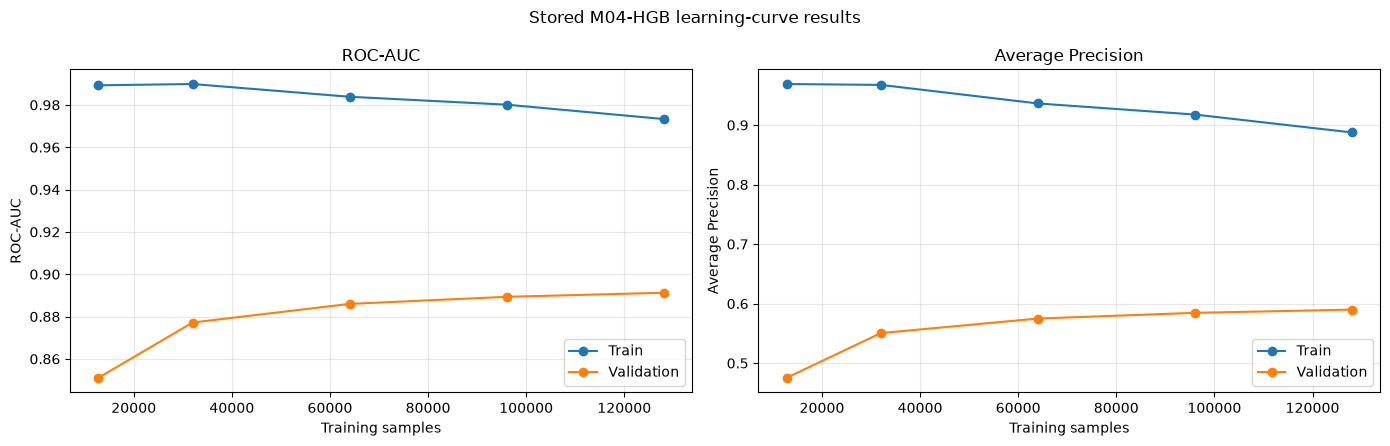

In [5]:
learning_curve_results = pd.read_csv(artifact_path('reports/tables/M04-HGB-learning-curve.csv'))
display(learning_curve_results.style.format('{:.6f}', subset=learning_curve_results.columns[1:]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
plot_specs = [
    ('roc_auc', 'ROC-AUC'),
    ('average_precision', 'Average Precision'),
]
for axis, (metric_key, label) in zip(axes, plot_specs):
    axis.plot(learning_curve_results['train_size'], learning_curve_results[f'train_{metric_key}_mean'], marker='o', label='Train')
    axis.plot(learning_curve_results['train_size'], learning_curve_results[f'validation_{metric_key}_mean'], marker='o', label='Validation')
    axis.set_title(label)
    axis.set_xlabel('Training samples')
    axis.set_ylabel(label)
    axis.grid(alpha=0.3)
    axis.legend()
fig.suptitle('Stored M04-HGB learning-curve results')
fig.tight_layout()
plt.show()


## Training-only OOF evaluation — M04-HGB-OOF-001

These are aggregated five-fold out-of-fold results from the training partition. At the unchanged 0.5 classification threshold, precision is relatively high while recall is considerably lower. Many predicted positives are correct, but a substantial number of actual positive cases remain undetected. This notebook does not claim that 0.5 is optimal.

In [6]:
oof_metrics = read_json('reports/tables/M04-HGB-OOF-001_metrics.json')
oof_metric_table = pd.DataFrame(
    [{'Metric': label, 'OOF value': oof_metrics[key]} for key, label in metric_labels.items()]
)
display(oof_metric_table.style.format({'OOF value': '{:.6f}'}))

confusion_counts = pd.DataFrame(
    [[oof_metrics['true_negatives'], oof_metrics['false_positives']], [oof_metrics['false_negatives'], oof_metrics['true_positives']]],
    index=['Actual Negative', 'Actual Positive'],
    columns=['Predicted Negative', 'Predicted Positive'],
)
display(confusion_counts)


,Metric,OOF value
0,ROC-AUC,0.891438
1,Average Precision,0.590860
2,F1,0.415242
3,Precision,0.795527
4,Recall,0.280943
5,Accuracy,0.920488
6,Balanced Accuracy,0.636438


,Predicted Negative,Predicted Positive
Actual Negative,142761,1161
Actual Positive,11561,4517


## ROC and Precision-Recall diagnostics

The following diagnostics plot the stored OOF curve coordinates; no predictions are regenerated.

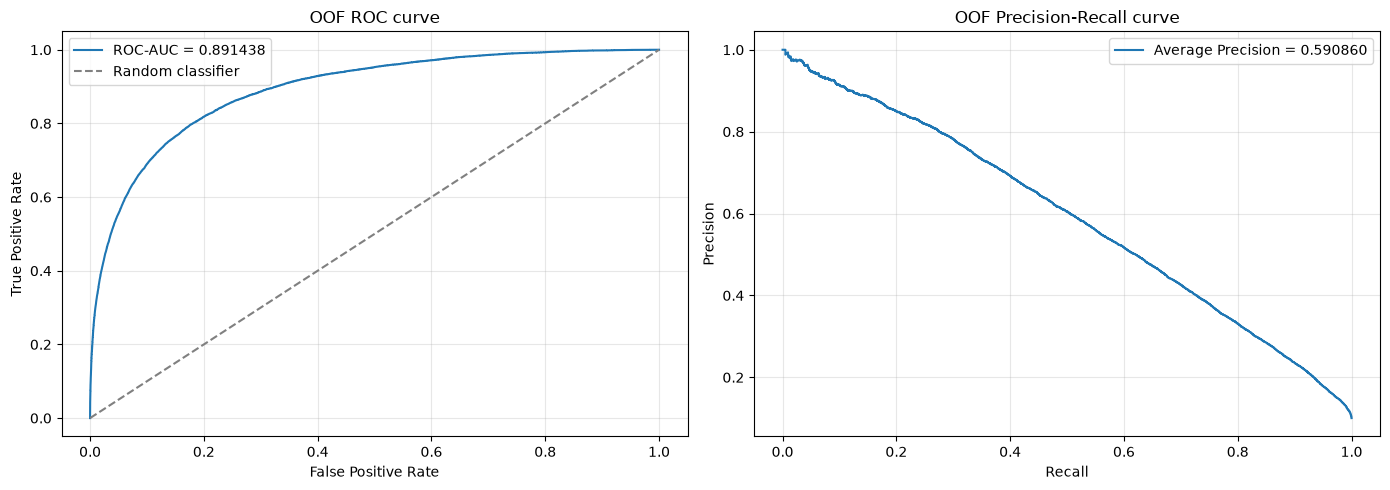

In [7]:
roc_curve = pd.read_csv(artifact_path('reports/tables/M04-HGB-OOF-001_roc_curve.csv'))
pr_curve = pd.read_csv(artifact_path('reports/tables/M04-HGB-OOF-001_precision_recall_curve.csv'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(roc_curve['false_positive_rate'], roc_curve['true_positive_rate'], label=f"ROC-AUC = {oof_metrics['roc_auc']:.6f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='OOF ROC curve')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(pr_curve['recall'], pr_curve['precision'], label=f"Average Precision = {oof_metrics['average_precision']:.6f}")
axes[1].set(xlabel='Recall', ylabel='Precision', title='OOF Precision-Recall curve')
axes[1].grid(alpha=0.3)
axes[1].legend()
fig.tight_layout()
plt.show()


## Confusion matrix

This visualization uses the stored OOF count totals directly.

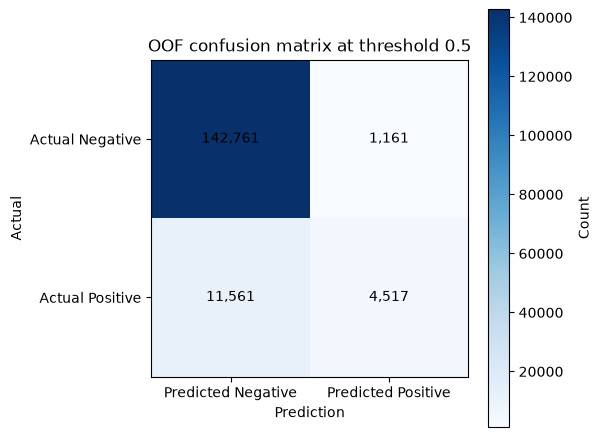

In [8]:
fig, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(confusion_counts.values, cmap='Blues')
axis.set_xticks(range(2), confusion_counts.columns)
axis.set_yticks(range(2), confusion_counts.index)
axis.set_xlabel('Prediction')
axis.set_ylabel('Actual')
axis.set_title('OOF confusion matrix at threshold 0.5')
for row in range(2):
    for column in range(2):
        axis.text(column, row, f"{confusion_counts.iloc[row, column]:,}", ha='center', va='center')
fig.colorbar(image, ax=axis, label='Count')
fig.tight_layout()
plt.show()


## Baseline vs tuned comparison — M04-HGB-COMP-001

All seven compared metrics increased. Baseline values are five-fold validation means, while tuned values are metrics from aggregated five-fold OOF predictions. They are closely comparable training-only estimates, but they are not an independent final-test comparison.

,metric,baseline_value,tuned_value,absolute_change
0,ROC-AUC,0.884596,0.891438,+0.006841
1,Average Precision,0.572879,0.590860,+0.017981
2,F1,0.387255,0.415242,+0.027986
3,Precision,0.782671,0.795527,+0.012856
4,Recall,0.257307,0.280943,+0.023636
5,Accuracy,0.918181,0.920488,+0.002306
6,Balanced Accuracy,0.624658,0.636438,+0.011780


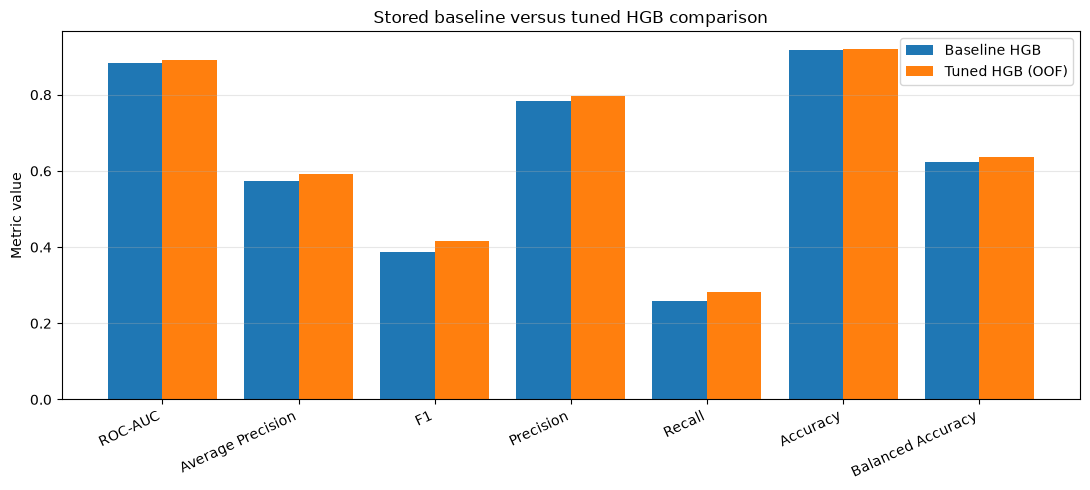

In [9]:
comparison = pd.read_csv(artifact_path('reports/tables/M04-HGB-model-comparison.csv'))
display(comparison.style.format({'baseline_value': '{:.6f}', 'tuned_value': '{:.6f}', 'absolute_change': '{:+.6f}'}))

positions = range(len(comparison))
fig, axis = plt.subplots(figsize=(11, 5))
axis.bar([position - 0.2 for position in positions], comparison['baseline_value'], width=0.4, label='Baseline HGB')
axis.bar([position + 0.2 for position in positions], comparison['tuned_value'], width=0.4, label='Tuned HGB (OOF)')
axis.set_xticks(list(positions), comparison['metric'], rotation=25, ha='right')
axis.set_ylabel('Metric value')
axis.set_title('Stored baseline versus tuned HGB comparison')
axis.legend()
axis.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


## Final Member 4 summary

M04-HGB-001
→ M04-HGB-SEARCH-001
→ M04-HGB-LC-001
→ M04-HGB-OOF-001
→ M04-HGB-COMP-001
→ M04-HGB-002

This is the actual experimental chronology. M04-HGB-002 is the later formal registration of the configuration selected in M04-HGB-SEARCH-001; the earlier notebook section order is only a presentation choice. The selected HGB configuration is Member 4's tuned candidate for later group-level model selection; it is not final-test performance or the globally best project model.

## Reproducibility and leakage controls

- Project `random_state = 42`.
- The completed experiments used the common training/test split.
- The training fingerprint was verified during the relevant runs.
- The reserved-test fingerprint was verified, but reserved test observations were not evaluated.
- Hyperparameter search used training CV only.
- Learning-curve analysis used training data only.
- OOF evaluation used training data only.
- The comparison uses stored training-only results.
- No final-test metric is reported in this notebook.
- The reserved test partition remains untouched for later group-level final evaluation.